# Amazon Sales Data Analysis Report

**Internship:** Innobyte Services – Data Analyst Internship

**Name:** Mahima Sebastian

**Date:** July 2026

## Problem Statement

The objective of this project is to analyze Amazon sales data to identify sales trends, product performance, customer behavior, fulfillment efficiency, and geographical distribution. The insights obtained from this analysis can help improve business decisions and overall sales performance.

## Objectives

- Analyze overall sales trends.
- Identify top-selling product categories.
- Evaluate fulfillment methods.
- Analyze customer and geographical distribution.
- Generate business insights and recommendations.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Amazon Sale Report.csv")
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by,New,PendingS
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,Easy Ship,NaN,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,Easy Ship,NaN,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,NaN,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,Easy Ship,NaN,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,NaN,NaN,NaN


The dataset contains Amazon sales transaction details such as order ID, date, category, quantity, amount, fulfillment method, and shipping information.

In [5]:
# ==========================
# Data Cleaning
# ==========================

# Import libraries
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("Amazon Sale Report.csv")

# Display the first 5 rows
df.head()

# Check dataset information
print(df.info())

# Check dataset shape
print("Dataset Shape:", df.shape)

# Check for duplicate records
print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Remove rows where Amount is missing
df.dropna(subset=['Amount'], inplace=True)

# Fill missing Courier Status with 'Unknown'
df['Courier Status'].fillna('Unknown', inplace=True)

# Fill missing Fulfilled By with 'Not Specified'
df['fulfilled-by'].fillna('Not Specified', inplace=True)

# Remove completely empty columns
df.drop(columns=['New', 'PendingS'], inplace=True)

# Remove rows with missing shipping details
df.dropna(subset=['ship-city', 'ship-state', 'ship-postal-code', 'ship-country'], inplace=True)

# Remove invalid Quantity and Amount values
df = df[df['Qty'] >= 0]
df = df[df['Amount'] >= 0]

# Check data types
print("\nData Types:")
print(df.dtypes)

# Final missing value check
print("\nRemaining Missing Values:")
print(df.isnull().sum())

# Final dataset shape
print("\nFinal Dataset Shape:", df.shape)

# Save cleaned dataset
df.to_csv("Cleaned_Amazon_Sales.csv", index=False)

print("\nData Cleaning Completed Successfully!")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128976 entries, 0 to 128975
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128976 non-null  int64  
 1   Order ID            128976 non-null  object 
 2   Date                128976 non-null  object 
 3   Status              128976 non-null  object 
 4   Fulfilment          128976 non-null  object 
 5   Sales Channel       128976 non-null  object 
 6   ship-service-level  128976 non-null  object 
 7   Category            128976 non-null  object 
 8   Size                128976 non-null  object 
 9   Courier Status      128976 non-null  object 
 10  Qty                 128976 non-null  int64  
 11  currency            121176 non-null  object 
 12  Amount              121176 non-null  float64
 13  ship-city           128941 non-null  object 
 14  ship-state          128941 non-null  object 
 15  ship-postal-code    128941 non-nul

C:\Users\asusa\AppData\Local\Temp\ipykernel_15180\1637274085.py:28: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
C:\Users\asusa\AppData\Local\Temp\ipykernel_15180\1637274085.py:38: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Courier Status'].fillna('Unknown', inplace=True)
C:\Users\asusa\AppData\Local\Temp\ipykernel_15180\163727


Missing Values:
index                      0
Order ID                   0
Date                       0
Status                     0
Fulfilment                 0
Sales Channel              0
ship-service-level         0
Category                   0
Size                       0
Courier Status             0
Qty                        0
currency                7789
Amount                  7789
ship-city                 33
ship-state                33
ship-postal-code          33
ship-country              33
B2B                        0
fulfilled-by           89595
New                   128808
PendingS              128808
dtype: int64

Data Types:
index                          int64
Order ID                      object
Date                  datetime64[ns]
Status                        object
Fulfilment                    object
Sales Channel                 object
ship-service-level            object
Category                      object
Size                          object
Courier Status 

### Data Cleaning Summary

- Removed duplicate records.
- Converted the Date column to datetime format.
- Removed missing values.
- Dropped empty columns.
- Prepared the dataset for analysis.

### Observation

The cleaned dataset contains over 120,000 records with no significant missing values, making it suitable for further analysis.

### Insight

Sales reached their highest level during April 2022, indicating increased customer demand during this period.

# Product Analysis

Product analysis helps identify the most popular product categories, preferred sizes, and products generating the highest sales. This information supports inventory planning and marketing strategies.

Category
T-shirt     46969
Shirt       46628
Blazzer     14693
Trousers    10149
Perfume      1091
Wallet        881
Socks         419
Shoes         155
Watch           3
Name: count, dtype: int64


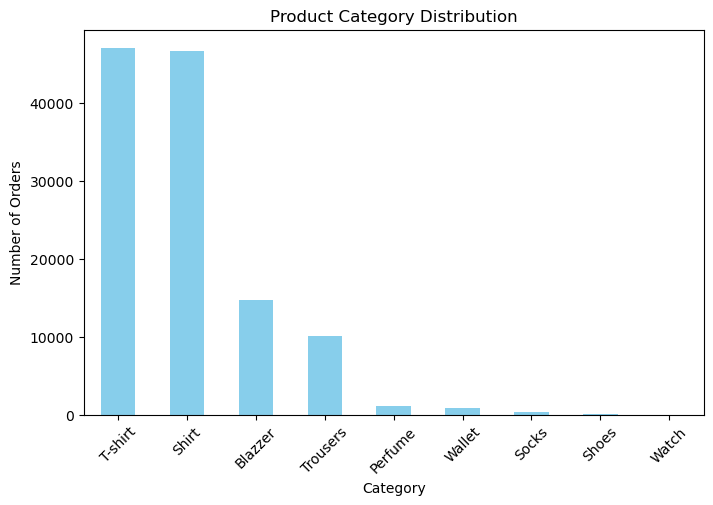

In [6]:
category_count = df['Category'].value_counts()

print(category_count)

plt.figure(figsize=(8,5))
category_count.plot(kind='bar', color='skyblue')

plt.title("Product Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

### Observation

- T-shirts and Shirts received the highest number of customer orders.
- Clothing products dominate the overall sales.

Category
T-shirt     39145184.17
Shirt       21261760.70
Blazzer     11207771.12
Trousers     5340325.30
Perfume       789419.66
Wallet        458408.18
Socks         150397.50
Shoes         123933.76
Watch            915.00
Name: Amount, dtype: float64


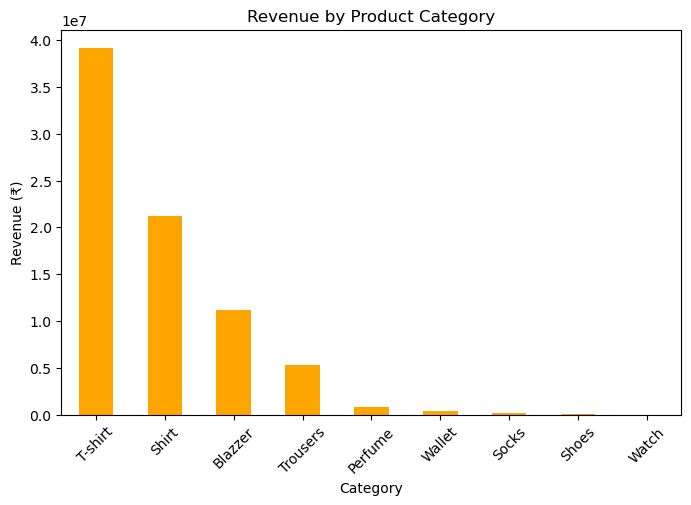

In [7]:
category_revenue = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

print(category_revenue)

plt.figure(figsize=(8,5))
category_revenue.plot(kind='bar', color='orange')

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)

plt.show()

### Observation

- The highest revenue was generated by the top-selling clothing categories.
- These categories contribute significantly to overall business revenue.

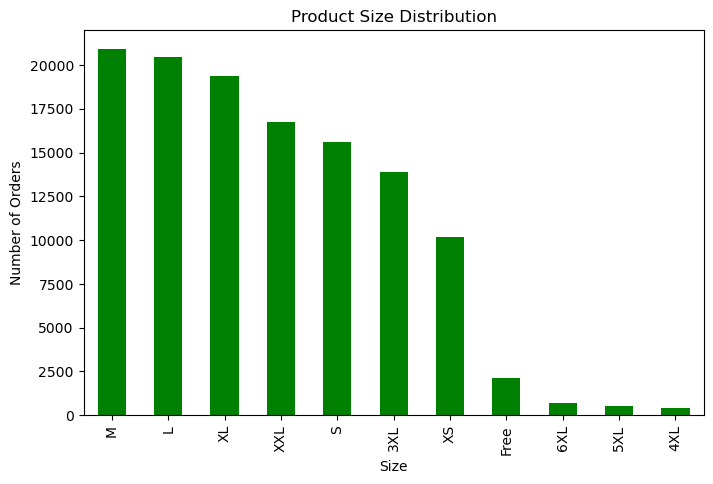

In [8]:
size_count = df['Size'].value_counts()

plt.figure(figsize=(8,5))
size_count.plot(kind='bar', color='green')

plt.title("Product Size Distribution")
plt.xlabel("Size")
plt.ylabel("Number of Orders")

plt.show()

### Observation

- Medium and Large sizes were the most preferred by customers.
- Maintaining sufficient inventory for these sizes can improve customer satisfaction.

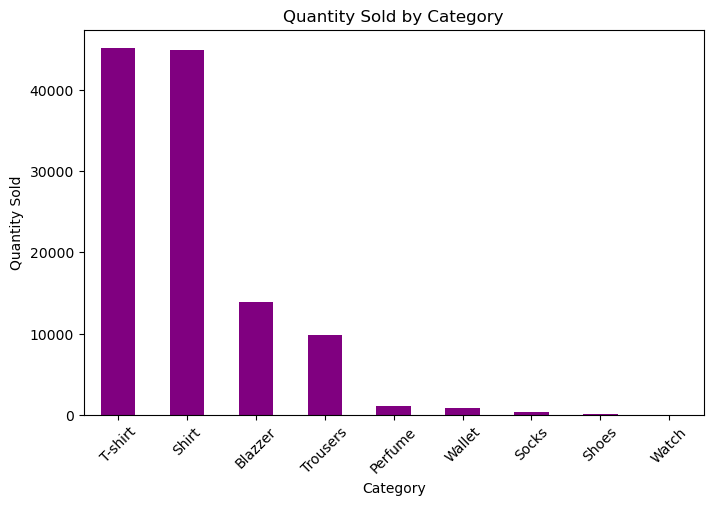

In [9]:
qty_category = df.groupby('Category')['Qty'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
qty_category.plot(kind='bar', color='purple')

plt.title("Quantity Sold by Category")
plt.xlabel("Category")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)

plt.show()

### Observation

- The categories with the highest quantity sold are also the major contributors to sales.
- These products should be prioritized during inventory planning.

# Fulfillment Analysis

This analysis evaluates the fulfillment methods used for order processing and delivery.

Fulfilment
Amazon      83524
Merchant    37464
Name: count, dtype: int64


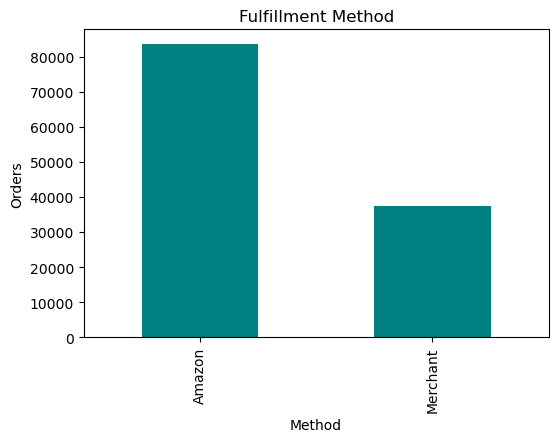

In [10]:
print(df['Fulfilment'].value_counts())

plt.figure(figsize=(6,4))

df['Fulfilment'].value_counts().plot(kind='bar', color='teal')

plt.title("Fulfillment Method")
plt.xlabel("Method")
plt.ylabel("Orders")

plt.show()

### Observation

- Amazon Fulfillment processed most of the customer orders.
- Merchant Fulfillment accounted for a smaller share.

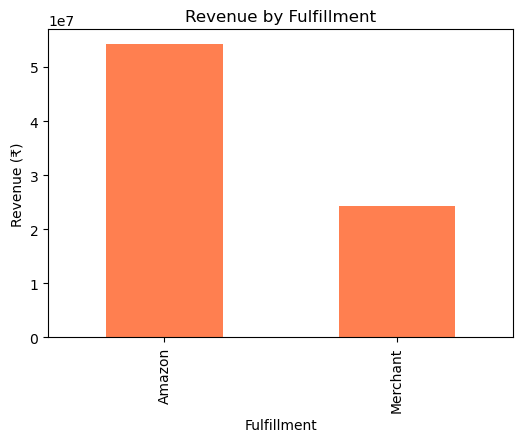

In [11]:
fulfillment_revenue = df.groupby('Fulfilment')['Amount'].sum()

plt.figure(figsize=(6,4))

fulfillment_revenue.plot(kind='bar', color='coral')

plt.title("Revenue by Fulfillment")
plt.xlabel("Fulfillment")
plt.ylabel("Revenue (₹)")

plt.show()

### Observation

- Amazon Fulfillment generated the highest revenue, indicating its effectiveness in handling customer orders.

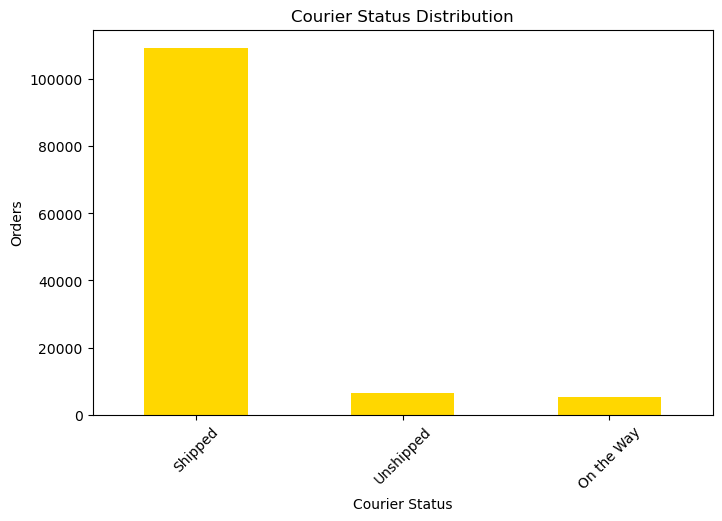

In [12]:
plt.figure(figsize=(8,5))

df['Courier Status'].value_counts().plot(kind='bar', color='gold')

plt.title("Courier Status Distribution")
plt.xlabel("Courier Status")
plt.ylabel("Orders")

plt.xticks(rotation=45)

plt.show()

### Observation

- Most orders were successfully shipped.
- Only a small number of orders were delayed or cancelled.

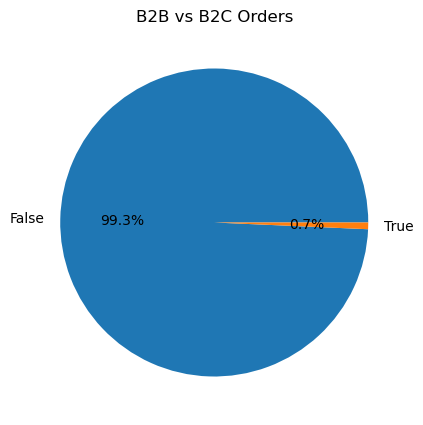

In [13]:
plt.figure(figsize=(5,5))

df['B2B'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.ylabel("")
plt.title("B2B vs B2C Orders")

plt.show()

### Observation

- Most orders were Business-to-Consumer (B2C).
- B2B orders represented only a small portion of total sales.

# Geographical Analysis

Geographical analysis identifies regions and cities that contribute the most to Amazon sales.

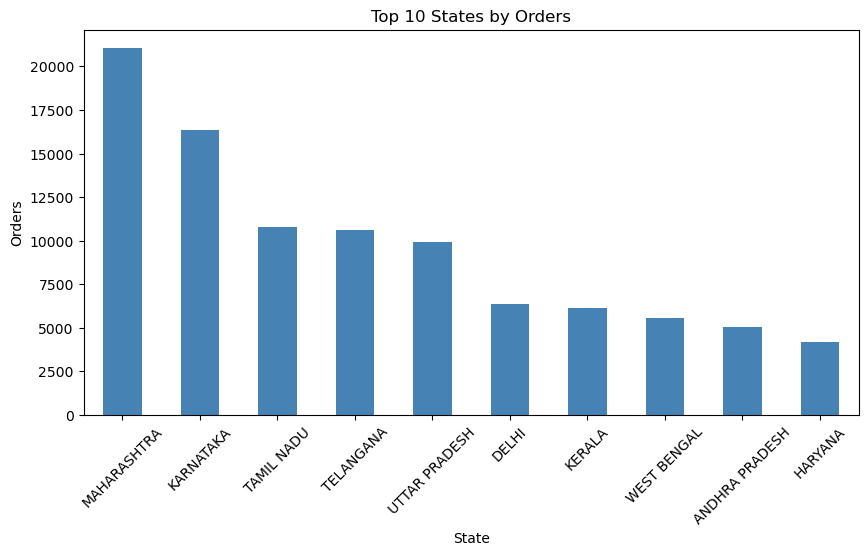

In [14]:
top_states = df['ship-state'].value_counts().head(10)

plt.figure(figsize=(10,5))

top_states.plot(kind='bar', color='steelblue')

plt.title("Top 10 States by Orders")
plt.xlabel("State")
plt.ylabel("Orders")

plt.xticks(rotation=45)

plt.show()

The highest number of orders was received from Maharashtra and Karnataka.

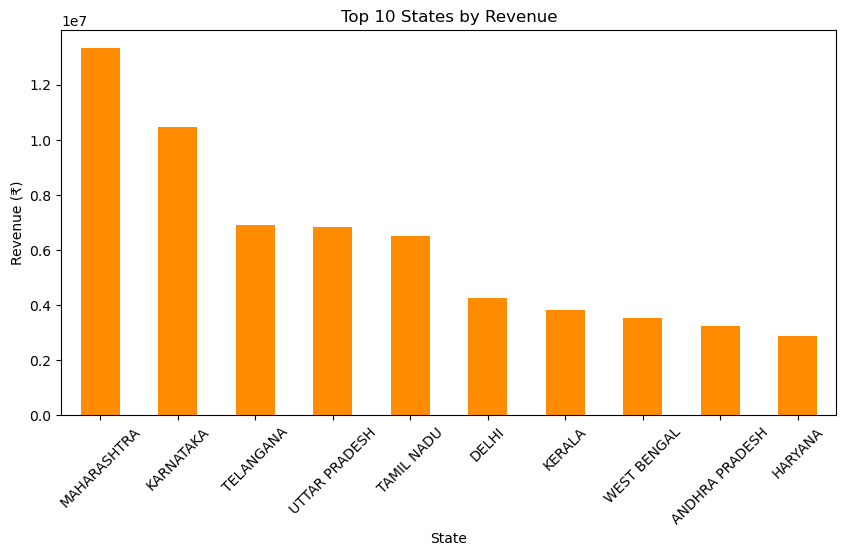

In [17]:
state_revenue = df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

state_revenue.plot(kind='bar', color='darkorange')

plt.title("Top 10 States by Revenue")
plt.xlabel("State")
plt.ylabel("Revenue (₹)")

plt.xticks(rotation=45)

plt.show()

The leading states generated a significant share of the total revenue.

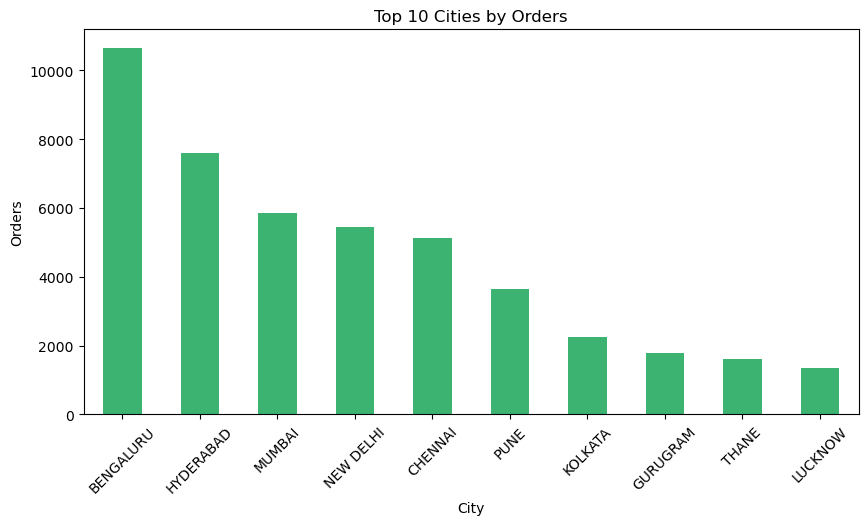

In [18]:
top_cities = df['ship-city'].value_counts().head(10)

plt.figure(figsize=(10,5))

top_cities.plot(kind='bar', color='mediumseagreen')

plt.title("Top 10 Cities by Orders")
plt.xlabel("City")
plt.ylabel("Orders")

plt.xticks(rotation=45)

plt.show()

Metropolitan cities accounted for the highest order volumes.

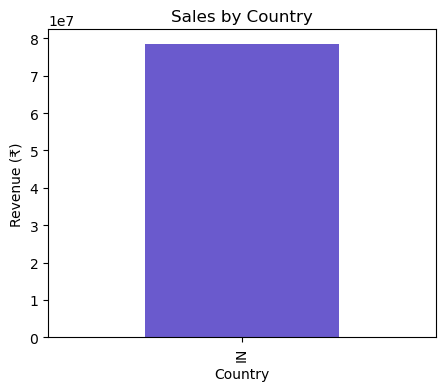

In [19]:
country_sales = df.groupby('ship-country')['Amount'].sum()

plt.figure(figsize=(5,4))

country_sales.plot(kind='bar', color='slateblue')

plt.title("Sales by Country")
plt.xlabel("Country")
plt.ylabel("Revenue (₹)")

plt.show()

All recorded sales were from India (IN), indicating that the dataset represents the Indian market.

# Business Insights

- The majority of orders were successfully fulfilled through Amazon Fulfillment.
- T-shirts and Shirts were among the best-selling product categories.
- Medium and Large sizes were the most preferred by customers.
- Maharashtra and Karnataka generated the highest sales.
- Most customers were B2C buyers.
- Total sales revenue exceeded ₹78 million.

# Recommendations

- Increase inventory for popular product categories and sizes.
- Focus marketing efforts on high-performing states and cities.
- Improve inventory planning during peak sales periods.
- Continue using Amazon Fulfillment to ensure efficient delivery.
- Promote low-selling products through targeted offers and discounts.

# Overall Findings

The analysis of the Amazon Sales dataset revealed several important business insights:

- The dataset contains over 120,000 sales records.
- Total sales revenue exceeded ₹78 million.
- Most orders were placed through Amazon.in.
- Amazon Fulfillment handled the majority of customer orders.
- Clothing categories such as T-shirts and Shirts received the highest number of orders.
- Medium and Large sizes were the most popular among customers.
- Maharashtra and Karnataka contributed the highest sales.
- Most customers were B2C buyers.

# Project Summary

This project involved analyzing Amazon sales data using Python.

The project included:

- Data Cleaning
- Exploratory Data Analysis (EDA)
- Sales Analysis
- Product Analysis
- Fulfillment Analysis
- Geographical Analysis
- Business Insights
- Recommendations

Python libraries such as Pandas, Matplotlib, and Seaborn were used to clean, analyze, and visualize the data.

# Future Scope

Future analysis can include:

- Customer segmentation using RFM analysis.
- Sales forecasting using machine learning.
- Product recommendation systems.
- Interactive dashboards using Power BI or Tableau.
- Demand prediction for inventory management.

# Conclusion

This project analyzed Amazon sales data to understand customer purchasing behavior, product performance, fulfillment methods, and geographical sales distribution. The analysis provided valuable insights that can help improve inventory management, optimize marketing strategies, enhance customer satisfaction, and support data-driven business decisions.

# Thank You

Thank you for reviewing this Amazon Sales Data Analysis Report.

This project was completed as part of the Data Analyst Internship at Innobyte Services.